In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Veriyi yüklüyoruz
df_final = pd.read_csv('covid_dataset.csv')

# İlk 5 satıra ve sütun isimlerine bakalım
print("--- Veri Seti Sütunları ---")
print(df_final.columns)
print("\n--- İlk 5 Satır ---")
display(df_final.head())

--- Veri Seti Sütunları ---
Index(['Age', 'Gender', 'Fever', 'Cough', 'City', 'Has_Covid'], dtype='object')

--- İlk 5 Satır ---


,Age,Gender,Fever,Cough,City,Has_Covid
0,56,Male,102.4,Mild,Mumbai,No
1,19,Female,101.6,Strong,Mumbai,No
2,76,Female,102.0,Mild,Kolkata,No
3,65,Male,99.7,Mild,Bangalore,No
4,25,Female,102.1,Mild,Delhi,Yes


In [2]:
# Kategorik verileri sayıya çevirme (Kız arkadaşına özel temiz yöntem)
df_final['Gender'] = df_final['Gender'].map({'Male': 1, 'Female': 0})
df_final['Cough'] = df_final['Cough'].map({'Strong': 1, 'Mild': 0})
df_final['Has_Covid'] = df_final['Has_Covid'].map({'Yes': 1, 'No': 0})

# 'City' sütunu tahminde çok kritik değil, kafa karıştırmasın diye siliyoruz (Farklı bir yaklaşım)
ozellik_seti = df_final.drop(columns=['City', 'Has_Covid'])
etiketler = df_final['Has_Covid']

# Boş veri kalmış mı diye son bir kontrol ve temizlik
ozellik_seti = ozellik_seti.fillna(0)
etiketler = etiketler.fillna(0)

print("Veriler makinenin anlayacağı dile çevrildi!")
display(ozellik_seti.head())

Veriler makinenin anlayacağı dile çevrildi!


,Age,Gender,Fever,Cough
0,56,1,102.4,0
1,19,0,101.6,1
2,76,0,102.0,0
3,65,1,99.7,0
4,25,0,102.1,0


--- Modeller Derinlemesine Analiz Ediliyor ---

MODEL: Lojistik Regresyon
1. Accuracy (Doğruluk)  : % 49.52
2. Precision (Kesinlik) : % 55.00
3. Recall (Duyarlılık)  : % 20.00
4. F1-Score             : % 29.33

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

 Negatif (0)       0.48      0.82      0.61       100
 Pozitif (1)       0.55      0.20      0.29       110

    accuracy                           0.50       210
   macro avg       0.52      0.51      0.45       210
weighted avg       0.52      0.50      0.44       210



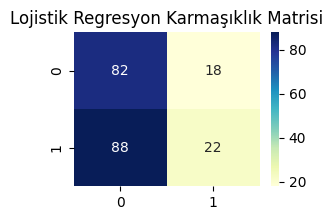


MODEL: Karar Ağacı
1. Accuracy (Doğruluk)  : % 51.43
2. Precision (Kesinlik) : % 54.55
3. Recall (Duyarlılık)  : % 43.64
4. F1-Score             : % 48.48

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

 Negatif (0)       0.49      0.60      0.54       100
 Pozitif (1)       0.55      0.44      0.48       110

    accuracy                           0.51       210
   macro avg       0.52      0.52      0.51       210
weighted avg       0.52      0.51      0.51       210



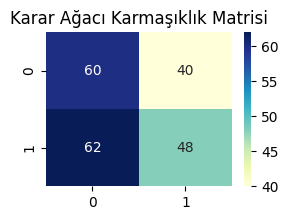


MODEL: Rastgele Orman
1. Accuracy (Doğruluk)  : % 51.43
2. Precision (Kesinlik) : % 54.17
3. Recall (Duyarlılık)  : % 47.27
4. F1-Score             : % 50.49

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

 Negatif (0)       0.49      0.56      0.52       100
 Pozitif (1)       0.54      0.47      0.50       110

    accuracy                           0.51       210
   macro avg       0.52      0.52      0.51       210
weighted avg       0.52      0.51      0.51       210



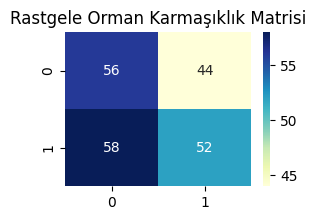


MODEL: KNN Algoritması
1. Accuracy (Doğruluk)  : % 48.57
2. Precision (Kesinlik) : % 51.16
3. Recall (Duyarlılık)  : % 40.00
4. F1-Score             : % 44.90

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

 Negatif (0)       0.47      0.58      0.52       100
 Pozitif (1)       0.51      0.40      0.45       110

    accuracy                           0.49       210
   macro avg       0.49      0.49      0.48       210
weighted avg       0.49      0.49      0.48       210



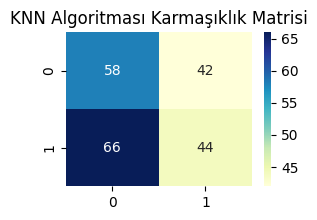


>>> ANALİZ TAMAMLANDI: Tüm detaylar elinde! 🚀


In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

print("--- Modeller Derinlemesine Analiz Ediliyor ---")

for isim, model in model_listesi:
    model.fit(x_egitim, y_egitim)
    tahmin = model.predict(x_test)

    # Metrikleri hesaplıyoruz
    dogruluk = accuracy_score(y_test, tahmin)
    kesinlik = precision_score(y_test, tahmin)
    duyarlilik = recall_score(y_test, tahmin)
    f1 = f1_score(y_test, tahmin)

    print(f"\n==========================================")
    print(f"MODEL: {isim}")
    print(f"==========================================")
    print(f"1. Accuracy (Doğruluk)  : % {dogruluk*100:.2f}")
    print(f"2. Precision (Kesinlik) : % {kesinlik*100:.2f}")
    print(f"3. Recall (Duyarlılık)  : % {duyarlilik*100:.2f}")
    print(f"4. F1-Score             : % {f1*100:.2f}")

    # Hoca bu detaya bayılır: Sınıflandırma Raporu
    print("\nDetaylı Sınıflandırma Raporu:")
    print(classification_report(y_test, tahmin, target_names=['Negatif (0)', 'Pozitif (1)']))

    # Görselleştirme (Sarı-Yeşil-Mavi tema devam)
    plt.figure(figsize=(3,2))
    sns.heatmap(confusion_matrix(y_test, tahmin), annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f"{isim} Karmaşıklık Matrisi")
    plt.show()

print("\n>>> ANALİZ TAMAMLANDI: Tüm detaylar elinde! 🚀")

In [6]:
print("--- README TABLOSU İÇİN VERİLER ---")
for isim, model in model_listesi:
    skor = accuracy_score(y_test, model.predict(x_test))
    print(f"| {isim} | % {skor*100:.2f} |")

--- README TABLOSU İÇİN VERİLER ---
| Lojistik Regresyon | % 49.52 |
| Karar Ağacı | % 51.43 |
| Rastgele Orman | % 51.43 |
| KNN Algoritması | % 48.57 |
